In [1]:
import os
import sys
sys.path.append('..')
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import colorcet as cc
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import matplotlib.animation as animation
from scipy.stats import linregress
from src.inversion_scripts.utils import plot_field, sum_total_emissions, get_posterior_emissions, get_mean_emissions

import matplotlib
import matplotlib.font_manager as fm
font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica.ttf'
fm.fontManager.addfont(font_path)
matplotlib.rcParams['font.family'] = 'Helvetica'

title_font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica-Bold.ttf'
title_font = fm.FontProperties(fname=title_font_path)

In [2]:
years = [2019, 2020, 2021, 2022, 2023, 2024]
all_dfs = []
for year in years:
    dir = f'/n/holylfs05/LABS/jacob_lab/Users/mhe/Global_{year}_annual/data_converted_extracted_fullyear'
    lat = np.load(f'{dir}/lat.npz')['lat'] # not at 2x2.5 yet
    lon = np.load(f'{dir}/lon.npz')['lon'] # not at 2x2.5 yet
    time = np.load(f'{dir}/time.npz')['time']
    obs = np.load(f'{dir}/obs_count.npz')['obs_count']
    y = np.load(f'{dir}/obs_tropomi.npz')['y']

    # convert time to datetime
    time_dt = pd.to_datetime(time, format='%Y%m%d')

    obs_rounded = np.round(obs)

    lat_regrid = np.round(lat / 2) * 2
    lon_regrid = np.round(lon / 2.5) * 2.5

    # combine time_dt, lat_regrid, lon_regrid, obs into a dataframe with time_dt as index
    df = pd.DataFrame({
        'time': time_dt,
        'lat': lat_regrid,
        'lon': lon_regrid,
        'obs': obs_rounded,
        'y': y
    })
    df['year'] = df['time'].dt.year
    df['months'] = df['time'].dt.to_period('M').dt.to_timestamp()
    all_dfs.append(df)

df_all = pd.concat(all_dfs, ignore_index=True)

In [3]:
print(df_all)

              time   lat    lon   obs            y  year     months
0       2019-01-01  44.0  145.0   0.0  1862.093750  2019 2019-01-01
1       2019-01-01  44.0  145.0   2.0  1853.910034  2019 2019-01-01
2       2019-01-01 -46.0  170.0  11.0  1768.785278  2019 2019-01-01
3       2019-01-01 -42.0  172.5   3.0  1751.318970  2019 2019-01-01
4       2019-01-01 -42.0  175.0   1.0  1770.373047  2019 2019-01-01
...            ...   ...    ...   ...          ...   ...        ...
3612007 2024-12-31  34.0 -117.5  21.0  1938.766724  2024 2024-12-01
3612008 2024-12-31  36.0 -117.5  33.0  1930.447021  2024 2024-12-01
3612009 2024-12-31  38.0 -117.5  21.0  1916.766235  2024 2024-12-01
3612010 2024-12-31  40.0 -117.5   1.0  1913.231445  2024 2024-12-01
3612011 2024-12-31  42.0 -117.5   1.0  1913.100708  2024 2024-12-01

[3612012 rows x 7 columns]


In [3]:
annual = (
    df_all
    .groupby(['year','lat','lon'])['y']
    .mean()
    .reset_index(name='y_annual')
)

da = (
    annual
    .set_index(['year','lat','lon'])['y_annual']
    .to_xarray()
)

In [4]:
## Plot each year separately

for year in years:
    da_year = da.sel(year=year)

    # Plot posterior emissions
    fig = plt.figure(figsize=(12, 8))
    plt.rcParams.update({"font.size": 16})
    ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

    title_font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica-Bold.ttf'
    title_font = fm.FontProperties(fname=title_font_path)

    cmap = plt.get_cmap('Spectral_r').copy()

    da_year.plot.pcolormesh(ax=ax,cmap=cmap, vmin=1800, vmax=1950, cbar_kwargs={"label": "ppb", "fraction": 0.02, "pad": 0.04, "extend": "both"}, transform=ccrs.PlateCarree())

    extent = [-170, 167.5, -60, 80]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    oceans_50m = cartopy.feature.NaturalEarthFeature("physical", "ocean", "50m")
    lakes_50m = cartopy.feature.NaturalEarthFeature("physical", "lakes", "50m")
    states_provinces_50m = cartopy.feature.NaturalEarthFeature(
        "cultural", "admin_1_states_provinces_lines", "50m"
    )
    ax.add_feature(cartopy.feature.BORDERS, facecolor="none", linewidth=0.6)
    ax.add_feature(oceans_50m, facecolor="none", edgecolor="black", linewidth=0.01)
    ax.coastlines(color='black')

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, alpha=0)
    gl.right_labels = False
    gl.top_labels = False

    plt.title(r"TROPOMI $X_{\mathrm{CH_4}}$" + f" ({year})", fontsize=20)
    # plt.show()

    # Save PNGs
    output_dir = "tropomi_frames"
    os.makedirs(output_dir, exist_ok=True)

    output_path = f"{output_dir}/frame_{year}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()


In [5]:
from PIL import Image
import glob

In [6]:
# Collect frames
frame_files = sorted(glob.glob("tropomi_frames/frame_*.png"))
frames = [Image.open(f) for f in frame_files]

# Save animated GIF
frames[0].save(
    "tropomi_xch4.gif",
    save_all=True,
    append_images=frames[1:],
    duration=1000,  # milliseconds per frame
    loop=0          # loop forever
)

In [30]:
# Trend for TROPOMI XCH4

annual = (
    df_all
    .groupby(['year','lat','lon'])['y']
    .mean()
    .reset_index(name='y_annual')
)

da = (
    annual
    .set_index(['year','lat','lon'])['y_annual']
    .to_xarray()
)

base_2019 = da.sel(year=2019)
da_percent_change = (da - base_2019) / base_2019 * 100

In [31]:
def _slope(years, values):
    # if all NaN or <2 points, return NaN
    # if np.isnan(values).all() or np.unique(years[~np.isnan(values)]).size < 2:
    #     return np.nan
    # return linregress(years, values).slope
    mask = ~np.isnan(values)
    if mask.sum() < 2:
        return np.nan
    res = linregress(years[mask], values[mask])
    return res.slope

years_arr = da_percent_change['year'].values.astype(float)

trends = xr.apply_ufunc(
    _slope,
    years_arr,
    da_percent_change,
    input_core_dims=[['year'], ['year']],
    vectorize=True
)

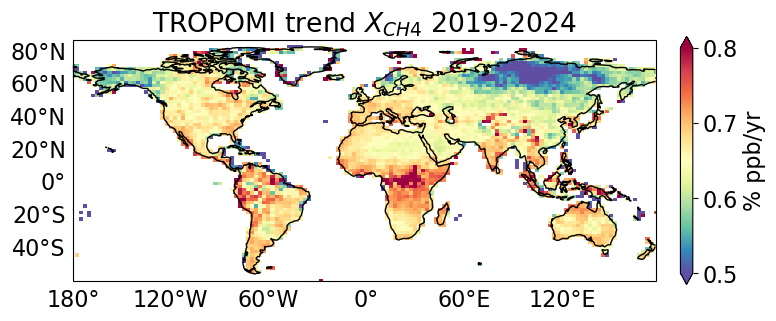

In [50]:
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

plot_field(
    ax,
    trends,
    cmap="Spectral_r",
    vmin=0.5,
    vmax=0.8,
    lon_bounds=[-180, 177.5],
    lat_bounds=[-60,88],
    title="TROPOMI trend $X_{CH4}$ 2019-2024",
    clean_title="TROPOMI XCH4",
    cbar_label="% ppb/yr",
    mask=None,
    only_ROI=False,
    is_regional=False,
    save_path=None
)

In [3]:
# Compute average y ("obs_tropomi") per grid cell
avg_xch4 = df_all.groupby(['lat', 'lon'])['y'].mean().reset_index()
total_obs = df_all.groupby(['lat', 'lon'])['obs'].sum().reset_index()

# combine
result = pd.merge(avg_xch4, total_obs, on=['lat', 'lon'])

ds = result.set_index(['lat', 'lon']).to_xarray()

In [4]:
ds

<xarray.Dataset> Size: 170kB
Dimensions:  (lat: 73, lon: 144)
Coordinates:
  * lat      (lat) float64 584B -60.0 -58.0 -56.0 -54.0 ... 78.0 80.0 82.0 84.0
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
Data variables:
    y        (lat, lon) float64 84kB nan nan nan nan nan ... nan nan nan nan nan
    obs      (lat, lon) float64 84kB nan nan nan nan nan ... nan nan nan nan nan

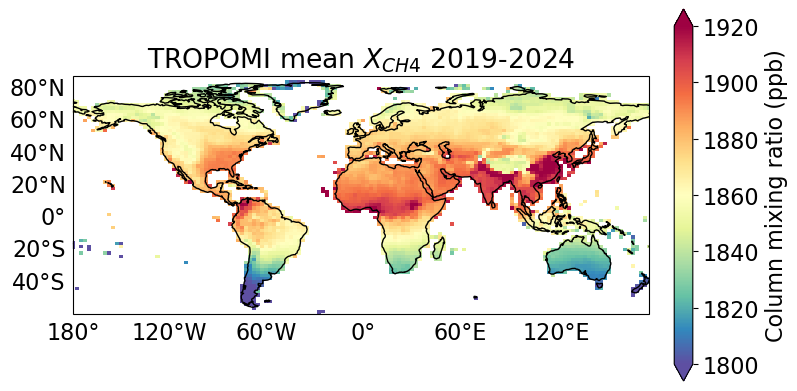

In [5]:
dynamic_range = lambda vals: (
    np.round(np.nanmedian(vals) / 25.0) * 25 - 25,
    np.round(np.nanmedian(vals) / 25.0) * 25 + 25,
)

fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

xch4_min, xch4_max = dynamic_range(ds["y"].values)

plot_field(
    ax,
    ds["y"],
    cmap="Spectral_r",
    vmin=1800,
    vmax=1920,
    lon_bounds=[-180, 177.5],
    lat_bounds=[-60,88],
    title="TROPOMI mean $X_{CH4}$ 2019-2024",
    clean_title="TROPOMI XCH4",
    cbar_label="Column mixing ratio (ppb)",
    mask=None,
    only_ROI=False,
    is_regional=False,
    save_path=None
)

# plt.savefig('figures/tropomi_xch4_2019-2024.png', dpi=300, bbox_inches='tight')

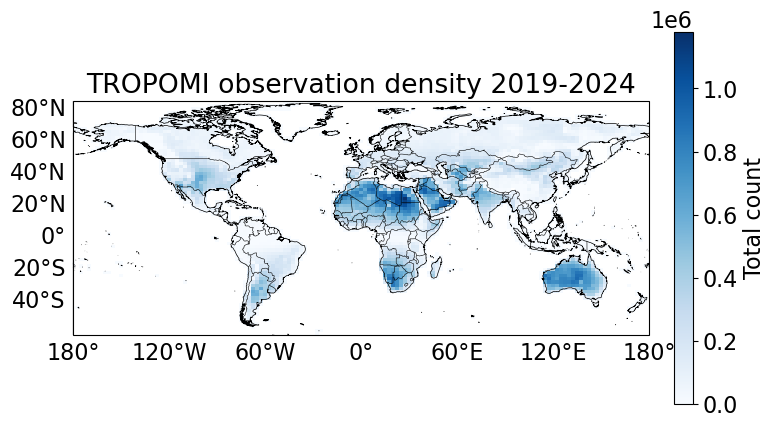

In [6]:
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
plot_field(
    ax,
    ds["obs"],
    cmap="Blues",
    plot_type="pcolormesh",
    vmin=0,
    vmax=np.nanmax(ds["obs"].values),
    lon_bounds=None,
    lat_bounds=None,
    title="TROPOMI observation density 2019-2024",
    cbar_label="Total count",
    mask=None,
    only_ROI=False,
)

# plt.savefig('figures/tropomi_obs_density.png', dpi=300, bbox_inches='tight')

In [31]:
df_2019to2023 = (
    df_all[
        (df_all['year'] < 2024) &
        (df_all['months'].dt.month >= 9) &
        (df_all['months'].dt.month <= 12)
    ]
    .groupby(['lat', 'lon'])['obs']
    .mean()
    .reset_index()
)
df_2024 = (
    df_all[
        (df_all['year'] == 2024) &
        (df_all['months'].dt.month >= 9) &
        (df_all['months'].dt.month <= 12)
    ]
    .groupby(['lat', 'lon'])['obs']
    .mean()
    .reset_index()
)

merged = pd.merge(df_2024, df_2019to2023, on=['lat', 'lon'], suffixes=('_2024', '_mean_2019to2023'))
merged['2024diff'] = merged['obs_2024'] - merged['obs_mean_2019to2023']

ds_anomaly = merged.set_index(['lat', 'lon']).to_xarray()

In [32]:
ds_anomaly

<xarray.Dataset> Size: 225kB
Dimensions:              (lat: 66, lon: 141)
Coordinates:
  * lat                  (lat) float64 528B -54.0 -52.0 -50.0 ... 72.0 74.0 76.0
  * lon                  (lon) float64 1kB -180.0 -177.5 -175.0 ... 175.0 177.5
Data variables:
    obs_2024             (lat, lon) float64 74kB nan nan nan nan ... nan nan nan
    obs_mean_2019to2023  (lat, lon) float64 74kB nan nan nan nan ... nan nan nan
    2024diff             (lat, lon) float64 74kB nan nan nan nan ... nan nan nan

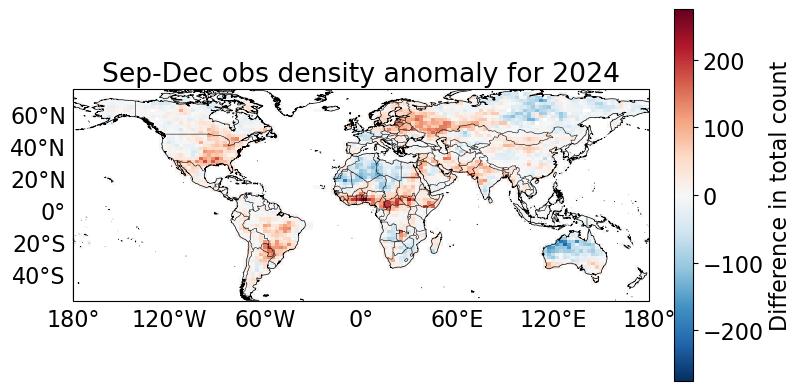

In [34]:
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
plot_field(
    ax,
    ds_anomaly["2024diff"],
    cmap="RdBu_r",
    plot_type="pcolormesh",
    # vmin=-200,
    # vmax=200,
    lon_bounds=None,
    lat_bounds=None,
    title="Sep-Dec obs density anomaly for 2024",
    cbar_label="Difference in total count",
    mask=None,
    only_ROI=False,
)